# Lab: Build a dense variational autoencoder for faces


## Environment and LFW data

In [1]:
# Kaggle images normally include these packages. For a minimal local environment:
# %pip install torch torchvision matplotlib pandas scikit-learn pillow

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 45
CHANNELS = 3
INPUT_DIM = CHANNELS * IMAGE_SIZE * IMAGE_SIZE
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
BETA = 1.0
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

# Change only this line for a local setup if LFW_DATASET_PATH is not set.
LOCAL_DATASET_PATH = Path("lfw-deepfunneled")

print(f"Running on {DEVICE}")


Running on cpu


In [2]:
def resolve_lfw_root():
    # Correct usage: os.environ.get() takes an env VAR NAME, not a literal path.
    env_path = os.environ.get("LFW_DATASET_PATH")
    candidates = []
    if env_path:
        candidates.append(Path(env_path).expanduser())
    if Path("/kaggle/input").exists():
        candidates.extend([
            Path("/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"),
            Path("/kaggle/input/lfw-deepfunneled/lfw-deepfunneled"),
        ])
    candidates.extend([
        LOCAL_DATASET_PATH.expanduser(),
        Path("lfw-deepfunneled"),
    ])

    for root in candidates:
        if root.exists() and next(root.rglob("*.jpg"), None) is not None:
            return root

    # Nothing found locally or on Kaggle: fall back to downloading the dataset
    # automatically via scikit-learn's built-in LFW fetcher (one-time, ~200MB,
    # cached afterward). This makes the notebook work on any machine with
    # internet access, without needing a manual download or path edit.
    print(
        "LFW dataset not found locally. Downloading it via scikit-learn "
        "(one-time, ~200MB, cached for future runs)..."
    )
    try:
        from sklearn.datasets import fetch_lfw_people

        download_home = Path("data/sklearn_lfw")
        download_home.mkdir(parents=True, exist_ok=True)
        fetch_lfw_people(
            data_home=str(download_home),
            min_faces_per_person=1,
            funneled=True,
            resize=1.0,
            color=True,
            download_if_missing=True,
        )
        downloaded_root = download_home / "lfw_home" / "lfw_funneled"
        if downloaded_root.exists() and next(downloaded_root.rglob("*.jpg"), None) is not None:
            return downloaded_root
        candidates.append(downloaded_root)
    except Exception as download_error:
        candidates.append(Path(f"<auto-download failed: {download_error}>"))

    checked = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(
        "No LFW .jpg files were found, and the automatic download did not "
        "produce them either. Attach lfw-dataset on Kaggle, set "
        "LFW_DATASET_PATH, edit LOCAL_DATASET_PATH, or check your internet "
        "connection. Checked:\n" + checked
    )


DATASET_ROOT = resolve_lfw_root()
image_paths = sorted(DATASET_ROOT.rglob("*.jpg"))
image_df = pd.DataFrame({
    "path": image_paths,
    "person": [path.parent.name for path in image_paths],
})

# Preserve the original notebook's balancing choice: remove identities with 25+
# photographs so a few celebrities do not dominate reconstruction training.
image_df = image_df.groupby("person", group_keys=False).filter(lambda rows: len(rows) < 25)
image_df = image_df.reset_index(drop=True)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Using {len(image_df):,} images from {image_df['person'].nunique():,} people")
image_df.head()


LFW dataset not found locally. Downloading it via scikit-learn (one-time, ~200MB, cached for future runs)...
Dataset root: data/sklearn_lfw/lfw_home/lfw_funneled
Using 10,645 images from 5,707 people


,path,person
0,data/sklearn_lfw/lfw_home/lfw_funneled/AJ_Cook...,AJ_Cook
1,data/sklearn_lfw/lfw_home/lfw_funneled/AJ_Lama...,AJ_Lamas
2,data/sklearn_lfw/lfw_home/lfw_funneled/Aaron_E...,Aaron_Eckhart
3,data/sklearn_lfw/lfw_home/lfw_funneled/Aaron_G...,Aaron_Guiel
4,data/sklearn_lfw/lfw_home/lfw_funneled/Aaron_P...,Aaron_Patterson


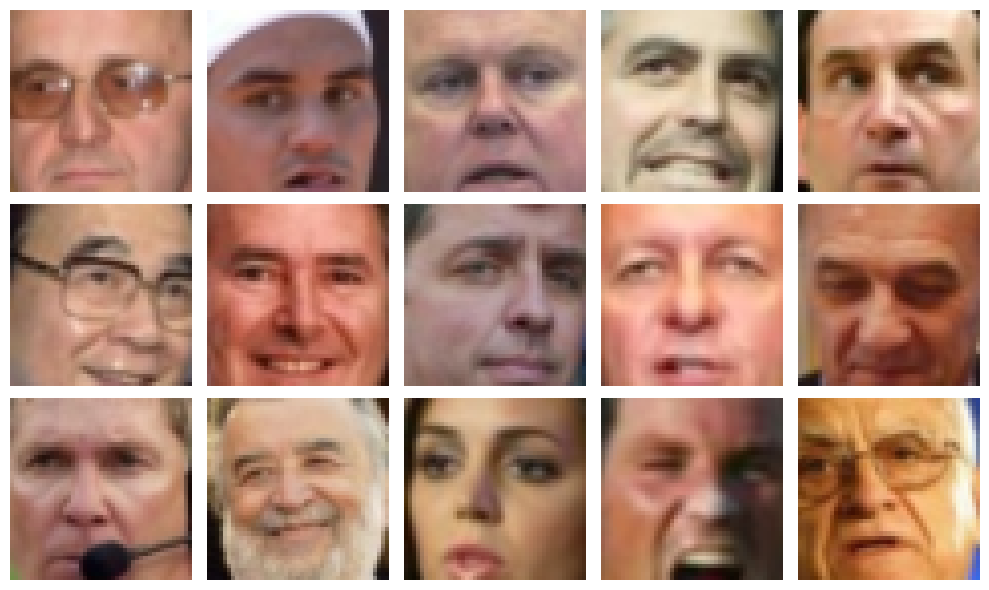

In [40]:
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        path = self.dataframe.loc[index, "path"]
        with Image.open(path) as image:
            image = image.convert("RGB")
            # LFW deep-funneled images are 250x250. This reproduces the original
            # notebook's central crop while remaining safe for other image sizes.
            width, height = image.size
            margin_x = min(80, max(0, (width - 1) // 3))
            margin_y = min(80, max(0, (height - 1) // 3))
            image = image.crop((margin_x, margin_y, width - margin_x, height - margin_y))
            return self.transform(image)


transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),  # pixel values in [0, 1]
])

train_df, val_df = train_test_split(image_df, test_size=0.2, random_state=SEED)
train_dataset = FaceDataset(train_df, transform)
val_dataset = FaceDataset(val_df, transform)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)

faces = next(iter(train_loader))
assert faces.ndim == 4 and faces.shape[1:] == (3, 45, 45)
assert 0 <= faces.min() and faces.max() <= 1

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for face, axis in zip(faces[:15], axes.flat):
    axis.imshow(face.permute(1, 2, 0))
    axis.axis("off")
plt.tight_layout()


##  From autoencoder to VAE


##  Implement the probabilistic encoder


In [41]:
class DenseFaceVAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1500),
            nn.ReLU(),
            nn.Linear(1500, 1000),
            nn.ReLU(),
        )

        # TODO 1: define self.mu_head and self.logvar_head.
        self.mu_head = nn.Linear(1000, latent_dim)
        self.logvar_head = nn.Linear(1000, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1500),
            nn.ReLU(),
            nn.Linear(1500, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        features = self.encoder(x.flatten(start_dim=1))
        return self.mu_head(features), self.logvar_head(features)

    def reparameterize(self, mu, logvar):
      std = torch.exp(0.5 * logvar)
      eps = torch.randn_like(std)
      return mu + eps * std
      raise NotImplementedError("Implement reparameterization")

    def decode(self, z):
        pixels = self.decoder(z)
        return pixels.view(-1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

    def forward(self, x):
      mu, logvar = self.encode(x)
      z = self.reparameterize(mu, logvar)
      reconstruction = self.decode(z)
      return reconstruction, mu, logvar
      raise NotImplementedError("Implement the VAE forward pass")


In [42]:
# These checks give fast feedback before expensive training.
model = DenseFaceVAE().to(DEVICE)
test_batch = faces[:4].to(DEVICE)
reconstruction, mu, logvar = model(test_batch)

assert reconstruction.shape == test_batch.shape
assert mu.shape == logvar.shape == (4, LATENT_DIM)
assert reconstruction.min() >= 0 and reconstruction.max() <= 1

# Sampling should normally give different z values, while gradients still reach
# both distribution heads.
z1 = model.reparameterize(mu, logvar)
z2 = model.reparameterize(mu, logvar)
assert not torch.equal(z1, z2)
(z1.mean()).backward()
assert model.mu_head.weight.grad is not None
assert model.logvar_head.weight.grad is not None
model.zero_grad(set_to_none=True)
print("Model checks passed.")


Model checks passed.


##  Implement the negative ELBO


In [43]:
def vae_loss(reconstruction, target, mu, logvar, beta=0.5):
  batch_size = target.shape[0]

  recon_term = F.binary_cross_entropy(
      reconstruction.view(batch_size, -1),
      target.view(batch_size, -1),
      reduction="sum",
  ) / batch_size

  kl_term = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size

  total = recon_term + beta * kl_term
  return total, recon_term, kl_term




In [44]:
# At mu=0 and logvar=0, q(z|x) equals the unit-normal prior, so KL must be zero.
dummy_x = torch.full((2, 3, 45, 45), 0.5, device=DEVICE)
dummy_mu = torch.zeros(2, LATENT_DIM, device=DEVICE)
dummy_logvar = torch.zeros_like(dummy_mu)
total, recon_term, kl_term = vae_loss(dummy_x, dummy_x, dummy_mu, dummy_logvar)
assert torch.isclose(kl_term, torch.tensor(0.0, device=DEVICE))
assert total.requires_grad is False  # dummy tensors do not require gradients

# With model outputs, the total must carry a gradient path.
reconstruction, mu, logvar = model(test_batch)
total, _, _ = vae_loss(reconstruction, test_batch, mu, logvar, beta=BETA)
assert total.requires_grad
print("Loss checks passed.")


Loss checks passed.


##  Train the VAE

In [45]:
def train_step(model, batch, optimizer, beta):
  model.train()
  batch = batch.to(DEVICE, non_blocking=True)

  optimizer.zero_grad(set_to_none=True)
  reconstruction, mu, logvar = model(batch)
  total, recon_term, kl_term = vae_loss(reconstruction, batch, mu, logvar, beta)
  total.backward()
  optimizer.step()

  return total.item(), recon_term.item(), kl_term.item()


Epoch 01 | train 3998.06 | val 3974.93 | recon 3951.74 | KL 23.19
Epoch 02 | train 3946.87 | val 3923.81 | recon 3903.97 | KL 19.84
Epoch 03 | train 3919.75 | val 3897.87 | recon 3880.39 | KL 17.49
Epoch 04 | train 3899.20 | val 3884.90 | recon 3868.04 | KL 16.86
Epoch 05 | train 3888.71 | val 3887.28 | recon 3870.25 | KL 17.03
Epoch 06 | train 3876.39 | val 3858.03 | recon 3840.89 | KL 17.14
Epoch 07 | train 3861.87 | val 3851.86 | recon 3834.61 | KL 17.25
Epoch 08 | train 3853.69 | val 3839.75 | recon 3823.25 | KL 16.51
Epoch 09 | train 3846.16 | val 3836.88 | recon 3821.34 | KL 15.54
Epoch 10 | train 3839.47 | val 3830.20 | recon 3815.64 | KL 14.56


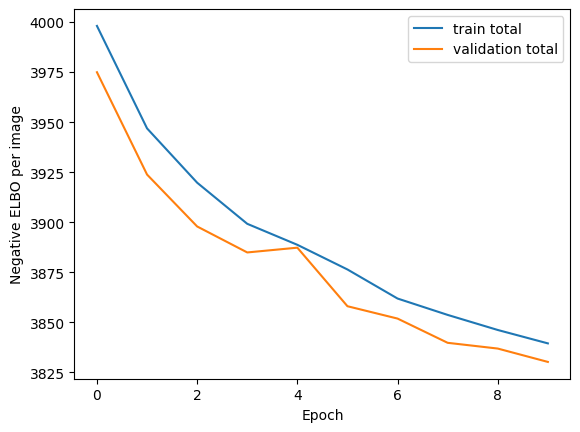

In [46]:
@torch.no_grad()
def evaluate(model, loader, beta):
    model.eval()
    totals = np.zeros(3, dtype=np.float64)
    examples = 0
    for batch in loader:
        batch = batch.to(DEVICE, non_blocking=True)
        reconstruction, mu, logvar = model(batch)
        values = vae_loss(reconstruction, batch, mu, logvar, beta)
        batch_size = batch.size(0)
        totals += np.array([value.item() for value in values]) * batch_size
        examples += batch_size
    return totals / examples


model = DenseFaceVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_total": [], "val_total": [], "val_reconstruction": [], "val_kl": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_total = 0.0
    seen = 0
    for batch in train_loader:
        total, reconstruction_term, kl_term = train_step(model, batch, optimizer, BETA)
        running_total += total * batch.size(0)
        seen += batch.size(0)

    val_total, val_reconstruction, val_kl = evaluate(model, val_loader, BETA)
    history["train_total"].append(running_total / seen)
    history["val_total"].append(val_total)
    history["val_reconstruction"].append(val_reconstruction)
    history["val_kl"].append(val_kl)
    print(
        f"Epoch {epoch:02d} | train {running_total / seen:.2f} | "
        f"val {val_total:.2f} | recon {val_reconstruction:.2f} | KL {val_kl:.2f}"
    )

plt.plot(history["train_total"], label="train total")
plt.plot(history["val_total"], label="validation total")
plt.xlabel("Epoch")
plt.ylabel("Negative ELBO per image")
plt.legend()
plt.show()


##  Inspect reconstructions

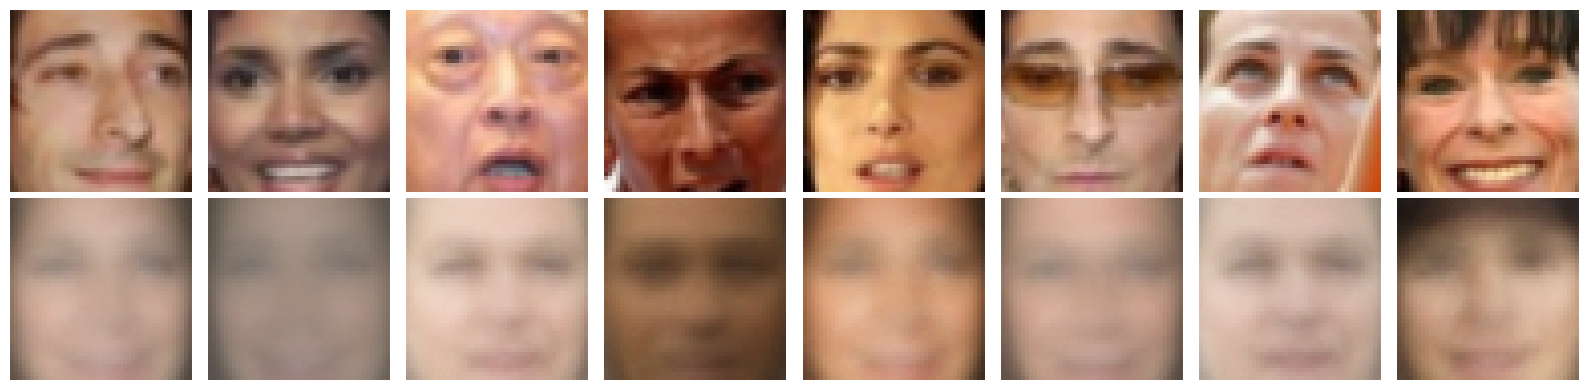

In [47]:
model.eval()
validation_faces = next(iter(val_loader))[:8].to(DEVICE)
with torch.no_grad():
    mu, _ = model.encode(validation_faces)
    reconstructed_faces = model.decode(mu)

originals = validation_faces.cpu()
reconstructed_faces = reconstructed_faces.cpu()
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for index in range(8):
    axes[0, index].imshow(originals[index].permute(1, 2, 0))
    axes[1, index].imshow(reconstructed_faces[index].permute(1, 2, 0).clamp(0, 1))
    axes[0, index].axis("off")
    axes[1, index].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")
plt.tight_layout()


##  Generate new faces

Reconstruction conditions on an existing face. Generation does not: it draws from the prior and sends those latent vectors directly to the decoder.


In [48]:
model.eval()
with torch.no_grad():
  z = torch.randn(10, LATENT_DIM, device=DEVICE)
  generated_faces = model.decode(z)


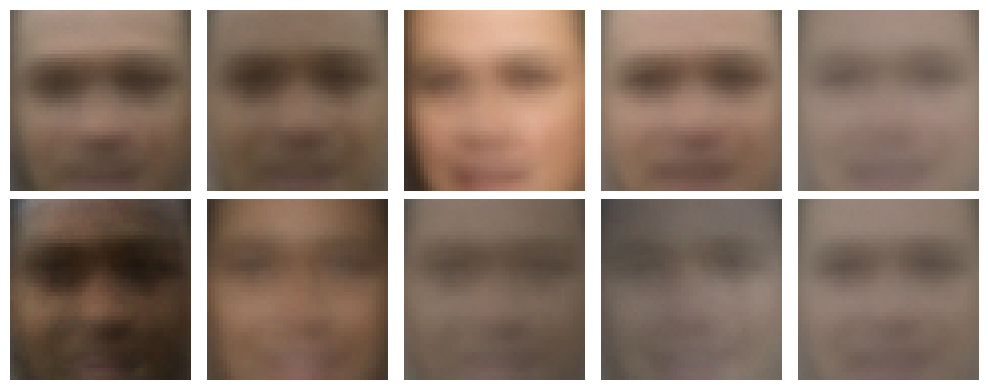

In [49]:
assert generated_faces.shape == (10, 3, 45, 45)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for face, axis in zip(generated_faces.cpu(), axes.flat):
    axis.imshow(face.permute(1, 2, 0).clamp(0, 1))
    axis.axis("off")
plt.tight_layout()
